In [2]:
# ===== AUTO EXPORT ALL CHARTS (MATPLOTLIB + SEABORN + PLOTLY) =====

import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

# create visuals folder
os.makedirs("visuals", exist_ok=True)

# chart counter
_chart_counter = 1

# -------- MATPLOTLIB / SEABORN AUTO SAVE --------

_original_show = plt.show

def auto_save_show(*args, **kwargs):
    global _chart_counter
    
    filename = f"visuals/chart_{_chart_counter}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Saved: {filename}")
    
    _chart_counter += 1
    _original_show(*args, **kwargs)

plt.show = auto_save_show


# -------- PLOTLY AUTO SAVE --------

_original_plotly_show = go.Figure.show

def auto_plotly_show(self, *args, **kwargs):
    global _chart_counter
    
    filename = f"visuals/chart_{_chart_counter}.png"
    self.write_image(filename)
    print(f"Saved: {filename}")
    
    _chart_counter += 1
    _original_plotly_show(self, *args, **kwargs)

go.Figure.show = auto_plotly_show

#### Problem Statement

xyz co's 2014-2018 sales data to identify key revenue and profit drivers across products,channels and regions,uncover seasonal trends and outliers, and align performance against budgets. Use these insights to optimize pricing, promotions and market expansion for sustainable growth and reduced concentration risk.


In [3]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [4]:
sheets = pd.read_excel('regional_sales.xlsx', sheet_name=None)
sheets

{'Sales Orders':         OrderNumber  OrderDate  Customer Name Index      Channel  \
 0       SO - 000225 2014-01-01                  126    Wholesale   
 1      SO - 0003378 2014-01-01                   96  Distributor   
 2      SO - 0005126 2014-01-01                    8    Wholesale   
 3      SO - 0005614 2014-01-01                   42       Export   
 4      SO - 0005781 2014-01-01                   73    Wholesale   
 ...             ...        ...                  ...          ...   
 64099  SO - 0007573 2018-02-28                   74    Wholesale   
 64100  SO - 0007706 2018-02-28                   51       Export   
 64101  SO - 0007718 2018-02-28                  136  Distributor   
 64102  SO - 0008084 2018-02-28                  158  Distributor   
 64103  SO - 0008654 2018-02-28                   22  Distributor   
 
       Currency Code Warehouse Code  Delivery Region Index  \
 0               USD         AXW291                    364   
 1               USD         A

In [5]:
# Assign dataframes to each sheets
df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budgets = sheets['2017 Budgets']

In [6]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [7]:
df_sales.shape

(64104, 12)

In [8]:
print('df_sales shape:', df_sales.shape)
print('df_customers shape:', df_customers.shape)
print('df_products shape:', df_products.shape)
print('df_regions shape:', df_regions.shape)
print('df_state_reg shape:', df_state_reg.shape)
print('df_budgets shape:', df_budgets.shape)

df_sales shape: (64104, 12)
df_customers shape: (175, 2)
df_products shape: (30, 2)
df_regions shape: (994, 15)
df_state_reg shape: (49, 3)
df_budgets shape: (30, 2)


In [9]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [10]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [11]:
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [12]:
df_budgets.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [13]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [14]:
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [15]:
new_header = df_state_reg.iloc[0]  # grab the first row for the header
df_state_reg.columns = new_header  # set the header row as the df header
df_state_reg = df_state_reg[1:].reset_index(
    drop=True)  # take the data less the header row
df_state_reg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [16]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [17]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [18]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [19]:
df_budgets.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

### data cleaning and wrangling


In [20]:
# Merge with customers
df = df_sales.merge(df_customers,
                    how='left',
                    left_on='Customer Name Index',
                    right_on='Customer Index'
                    )

In [21]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [22]:
# Merge with products
df = df.merge(df_products,
              how='left',
              left_on='Product Description Index',
              right_on='Index')

In [23]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [24]:
# Merge with regions
df = df.merge(df_regions,
              how='left',
              left_on='Delivery Region Index',
              right_on='id')

In [25]:
df.head(1)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York


In [26]:
df = df.merge(df_state_reg[["State Code", "Region"]],
              how='left',
              left_on='state_code',
              right_on='State Code')

In [27]:
# Merge with budgets
df = df.merge(df_budgets,
              how='left',
              on='Product Name')

In [28]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [29]:
df.to_csv('files.csv')

In [30]:
# Cleaning up redudnant columns
cols_to_drop = ['Customer Index', 'Index', 'id', 'State Code']
df = df.drop(columns=cols_to_drop, errors='ignore')

In [31]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [32]:
# convert all columns to lowercase for ease of use
df.columns = df.columns.str.lower()
df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [33]:
# keeping the important columns for analysis
cols_to_keep = ['ordernumber',
                'orderdate',
                'customer names',
                'channel',
                'product name',
                'order quantity',
                'unit price',
                'line total',
                'total unit cost',
                'state_code',
                'county',
                'state',
                'region',
                'latitude',
                'longitude',
                'median_income',
                '2017 budgets']

In [34]:
df = df[cols_to_keep]

In [35]:
df.head()

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,median_income,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,36466,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,54176,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,124759,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,30019,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,63158,1085037.329


In [36]:
# Rename the columns

df = df.rename(columns={'ordernumber': 'order_number',
                        'orderdate': 'order_date',
                        'customer names': 'customer_name',
                        'product name': 'product_name',
                        'order quantity': 'order_quantity',
                        'unit price': 'unit_price',
                        'line total': 'revenue',
                        'total unit cost': 'total_unit_cost',
                        '2017 budgets': 'budget'})
df.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state,region,latitude,longitude,median_income,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,36466,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,54176,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,124759,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,30019,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,63158,1085037.329


In [37]:
# Blank out budgets for non-2017 orders
df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA
# Line total is revenue
df[['order_date', 'product_name', 'revenue', 'budget']].head()

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [38]:
df

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state,region,latitude,longitude,median_income,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,36466,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,54176,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,124759,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,30019,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,63158,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,Bucks County,Pennsylvania,Northeast,40.15511,-74.82877,69878,NaN
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,Cook County,Illinois,Midwest,42.11030,-88.03424,71573,NaN
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,Broward County,Florida,South,26.24453,-80.20644,42786,NaN
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,Erie County,New York,Northeast,42.91002,-78.74182,48662,NaN


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64104 non-null  datetime64[ns]
 2   customer_name    64104 non-null  object        
 3   channel          64104 non-null  object        
 4   product_name     64104 non-null  object        
 5   order_quantity   64104 non-null  int64         
 6   unit_price       64104 non-null  float64       
 7   revenue          64104 non-null  float64       
 8   total_unit_cost  64104 non-null  float64       
 9   state_code       64104 non-null  object        
 10  county           64104 non-null  object        
 11  state            64104 non-null  object        
 12  region           64104 non-null  object        
 13  latitude         64104 non-null  float64       
 14  longitude        64104 non-null  float

In [40]:
df.describe()

,order_date,order_quantity,unit_price,revenue,total_unit_cost,latitude,longitude,median_income,budget
count,64104,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,1.526300e+04
mean,2016-01-29 01:28:20.935979008,8.441689,2284.380803,19280.682937,1432.083899,37.769427,-94.247116,59396.944325,2.989305e+06
min,2014-01-01 00:00:00,5.000000,167.500000,837.500000,68.675000,25.468720,-123.262040,0.000000,5.944716e+05
25%,2015-01-13 00:00:00,6.000000,1031.800000,8019.900000,606.216000,33.953330,-112.034140,43163.000000,1.672229e+06
50%,2016-01-27 00:00:00,8.000000,1855.900000,14023.100000,1084.495500,39.114170,-88.200900,53587.500000,3.016489e+06
75%,2017-02-13 00:00:00,10.000000,3606.275000,27416.400000,2046.933750,41.676550,-80.407000,71897.000000,3.925425e+06
max,2018-02-28 00:00:00,12.000000,6566.000000,78711.600000,5498.556000,48.759550,-70.255330,149837.000000,5.685138e+06
std,NaN,2.276217,1663.598141,15429.602766,1107.705728,5.068599,16.884334,21556.192739,1.557271e+06


In [41]:
# Filter the dataset to only include orders from 2017 for the EDA, since the budgets are only for 2017
df_2017 = df[df['order_date'].dt.year == 2017]

In [42]:
df.isnull().sum()

order_number           0
order_date             0
customer_name          0
channel                0
product_name           0
order_quantity         0
unit_price             0
revenue                0
total_unit_cost        0
state_code             0
county                 0
state                  0
region                 0
latitude               0
longitude              0
median_income          0
budget             48841
dtype: int64

In [43]:
df_2017.isnull().sum()

order_number       0
order_date         0
customer_name      0
channel            0
product_name       0
order_quantity     0
unit_price         0
revenue            0
total_unit_cost    0
state_code         0
county             0
state              0
region             0
latitude           0
longitude          0
median_income      0
budget             0
dtype: int64

In [44]:
df_2017.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state,region,latitude,longitude,median_income,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,41107,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,45358,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,42044,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,47450,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,41308,3050087.565


## **Feature Engineering**


In [45]:
df['total_cost'] = df['order_quantity'] * df['total_unit_cost']

In [46]:
df['profit'] = df['revenue'] - df['total_cost']
df['profit_margin_pct'] = df['profit'] / df['revenue'] * 100
df['order_month_name'] = df['order_date'].dt.month_name()
df['order_month_num'] = df['order_date'].dt.month
df.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,...,region,latitude,longitude,median_income,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,South,32.08354,-81.09983,36466,NaN,10946.058,4048.542,27.0,January,1
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Midwest,39.61366,-86.10665,54176,NaN,13969.098,11899.602,46.0,January,1
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,West,37.66243,-121.87468,124759,NaN,4108.440,1760.760,30.0,January,1
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,Midwest,39.16533,-86.52639,30019,NaN,7201.964,9166.136,56.0,January,1
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,Northeast,41.77524,-72.52443,63158,NaN,10082.160,8249.040,45.0,January,1


## **EDA**


Saved: visuals/chart_1.png


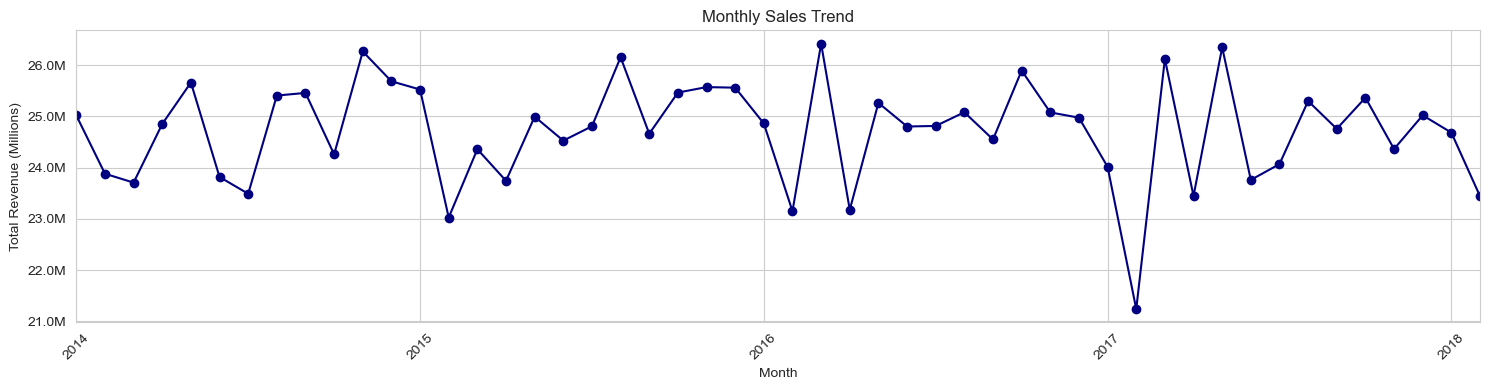

In [47]:
# Convert order_date to monthly period (e.g., 2022-01, 2022-02, etc.)
from matplotlib.ticker import FuncFormatter
df['order_month'] = df['order_date'].dt.to_period('M')

# Calculate total revenue for each month
monthly_sales = df.groupby('order_month')['revenue'].sum()

# Set figure size for clarity
plt.figure(figsize=(15, 4))

# Plot the monthly sales trend circle markers and navy line
monthly_sales.plot(marker='o', color='navy')

# Scale y-axis values to millions for better readability
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Add title and axis labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent clipping of labels
plt.tight_layout()
plt.show()

### Insights from the figure ---

Sales consistently cycle between \$24 M and \$26 M, with clear peaks in late spring to early summer (May-June) and troughs each january.

The overall trend remains stable y-o-y, reflecting a reliable seasonal demand pattern.

However, the sharp revenue drop in early 2017 stands out as an outlier, warranting closer investigation into potential causes sucha as market disruption or mistimed promotions.


## 2._Monthly Sales Trend (All year Combined)_

Goal: Highlight overall seasonality and patterns by aggregating sales across all years for each calender month

Chart: Line Chart

EDA Typer: Temporal (time series)

Structure: Line with Markers, months ordered January to December based on month number


Saved: visuals/chart_2.png


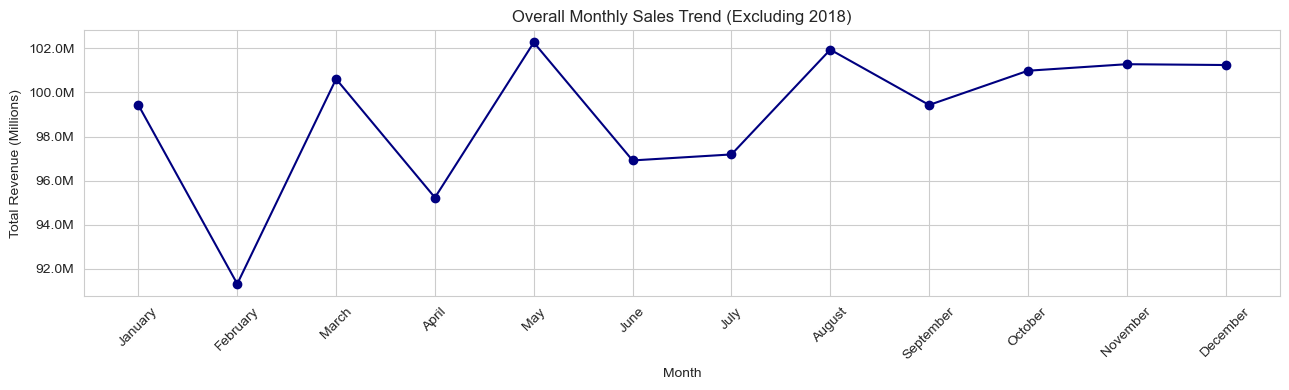

In [48]:
# 1. Filter out and 2018 orders
from matplotlib.ticker import FuncFormatter
df_ = df[df['order_date'].dt.year != 2018]

# 2. Group by month number and month name, sum revenue, then sort by month number
monthly_sales = df_.groupby(['order_month_num', 'order_month_name'])[
    'revenue'].sum().sort_index()

# 3. Plot setup

plt.figure(figsize=(13, 4))
plt.plot(
    monthly_sales.index.get_level_values(1),
    monthly_sales.values,
    marker='o',
    color='navy'
)

# 4. Scale y-axis values to millions for readability
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# 5. Add title and axis labels
plt.title('Overall Monthly Sales Trend (Excluding 2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

# 6. Rotate x-axis labels for readability
plt.xticks(rotation=45)

# 7. Adjust layout to prevent clipping
plt.tight_layout()

# 8. Display the plot
plt.show()

## Insights ---

Across all years, January begins strong with roughly $99M, followed by a steep decline through April's low point(~$95 M).

Sales rebound in May and August (~$102 M) before setting into a plateau of $99-101 M form September to December.

This pattern reveals a strong post-New year surge, a spring dip, and a mid-summer bump each calender year.


## 3.Top 10 Products by Revenue (in Millions)

Goal: Identify the highest-grossing products to focus marketing and inventory efforts

Chart:Horizontal bar chart

EDA Type:Univariate

Structure:Bars sorted descending to show top 10 prodcuts with revenue scaled in millions


C:\Users\Mudit PC\AppData\Local\Temp\ipykernel_25504\1197985446.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved: visuals/chart_3.png


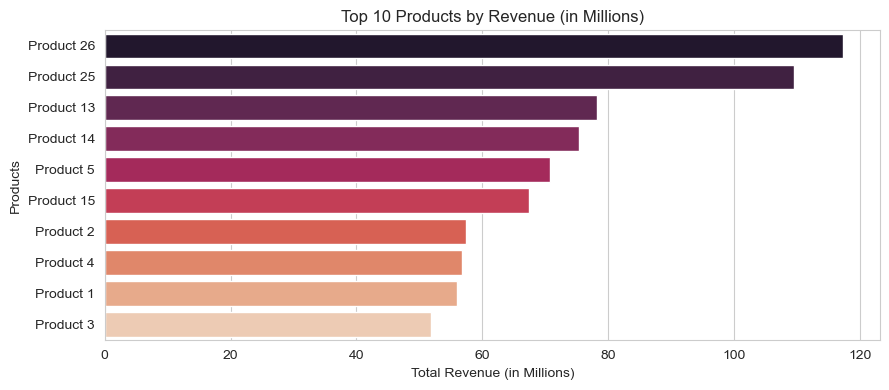

In [49]:
# Calculte total revenue for each product and convert values to millions for better readability
top_prod = df.groupby('product_name')['revenue'].sum()/1_000_000

# Select the top 10 products by revenue
top_prod = top_prod.nlargest(10)

# Set the figure size for clarity
plt.figure(figsize=(9, 4))

# Plot a horizontal bar chart where x-axis is revenue in millions and  y-axis is products
sns.barplot(
    x=top_prod.values,
    y=top_prod.index,
    palette='rocket'
)
# Add title and axis labels
plt.title('Top 10 Products by Revenue (in Millions)')
plt.xlabel('Total Revenue (in Millions)')
plt.ylabel('Products')

# Adjust layout to label overlap
plt.tight_layout()

# Display the plot
plt.show()

##Insights---

Products 25 and 26 pull awau at $118 M and $110 M, with a sharp drop to $78M for product 13 and a tight mid-pack at $68-$75M.

The bottom four cluster at $52-$57M, highlighting similar constraints.

Focus on growth pilots for the mid-tier and efficiency gains for the lower earners to drive significant lifts.


## 4.Top 10 products by avg profit margin

Goal: Compare average profitability across products to identify high-margin items

Chart: Horizontal bar chart

EDA Type: Univariate

Structure: Bars sorted descending to show top 10 products with average profit margin values


C:\Users\Mudit PC\AppData\Local\Temp\ipykernel_25504\332990340.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved: visuals/chart_4.png


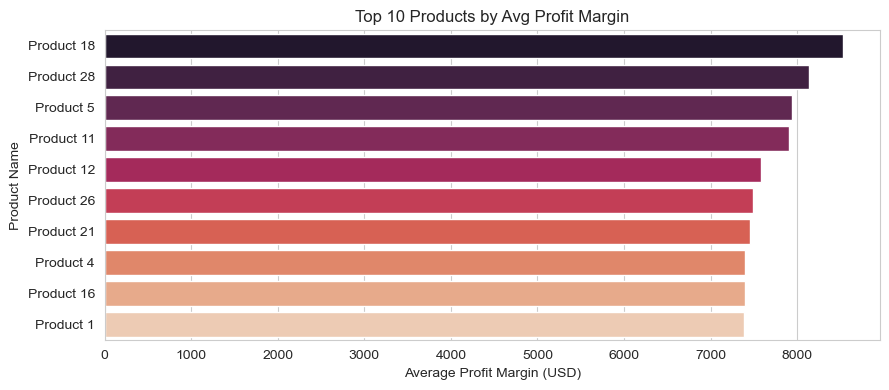

In [50]:
# 1.Compute average profit per product and take top 10
top_margin = (df.groupby('product_name')['profit']
                .mean()
                .sort_values(ascending=False)
                .head(10)
              )

# 2. Set figure size for clarity
plt.figure(figsize=(9, 4))

# 3 Plot a horizontal bar chart
sns.barplot(
    x=top_margin.values,
    y=top_margin.index,
    palette='rocket'
)

# 4. Add title and axis labels
plt.title('Top 10 Products by Avg Profit Margin')
plt.xlabel('Average Profit Margin (USD)')
plt.ylabel('Product Name')

# 5. Adjust layout to prevent label overlap
plt.tight_layout()

# 6. Display the plot
plt.show()

## 5. Sales by channel (Pie Chart)

Goal: Show distribution of total sales across channels to identify dominant sales routes

Chart: Pie Chart

EDA Type: Univariate

Structure: Pie segments with percentage labels, colors for clarity, start angle adjusted


Saved: visuals/chart_5.png


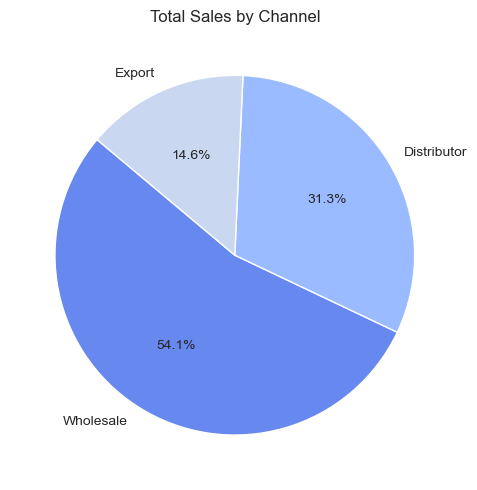

In [51]:
# Group revenue by sales channel and sort descending
chan_sales = df.groupby('channel')[
    'revenue'].sum().sort_values(ascending=False)

# Set figure size for the pie chart
plt.figure(figsize=(5, 5))

# Plot pie chart with percentage labels and a defined start angle
plt.pie(
    chan_sales.values,
    labels=chan_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('coolwarm')
)

# Add title for context
plt.title('Total Sales by Channel')

# Adjust layout to ensure everything fits well
plt.tight_layout()

# Display the chart
plt.show()

## Insights ---

Wholesale accounts for 54% of sales, with distributors at ~31% and exports at ~15%, underscoring reliance on domestic bulk channels.

To diversify revenue and mitigate concentration risk, prioritize expanding export initiatives - thorugh targeted overseas marketing and strategic partner relationships.


## 6. Average Order Value (AOV) Distribution

Goal: Understand distribution of order values to identify typical spending levels and outliers

Chart: Histogram

EDA Type: Univariate

Structure: Histogram with 50 bins, colored bars with edge highlights to show frequency of order values.


Saved: visuals/chart_6.png


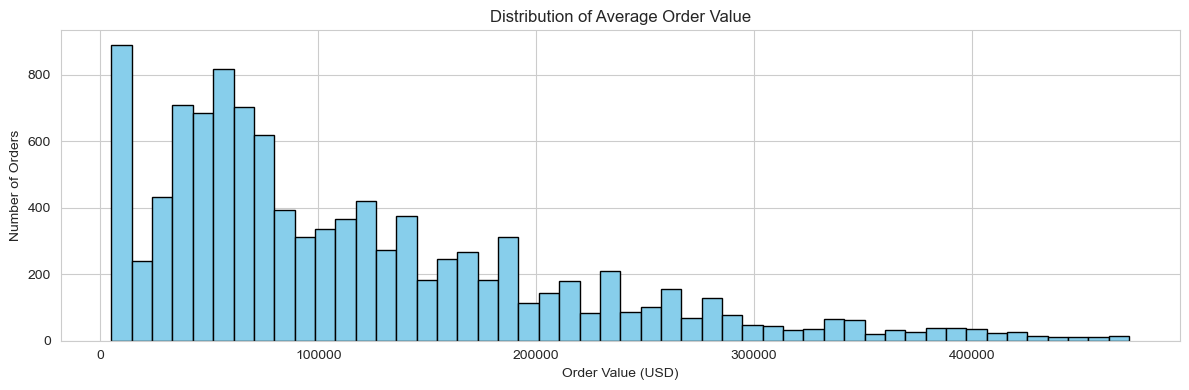

In [52]:
# Calculate the total revenue for each order to get the order value
aov = df.groupby('order_number')['revenue'].sum()

# Set the figure size for better visibility
plt.figure(figsize=(12, 4))

# Plot a histogram of order values
plt.hist(
    aov,
    bins=50,
    color='skyblue',
    edgecolor='black'
)

# Add title and axis labels for content

plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')

# Adjust layout to prevent cliping
plt.tight_layout()

# Show the plot
plt.show()

## Insights --

The order-value distribution is heavily right-skewed, with most orders clustering between $20K and $120 K and a pronounced mode around $50 K- $60K.
A Long tail of high-value transactions extends up toward $400 K- $500K, but these large orders represent only a small share of total volume.


### 7. Profit Margin % vs. Unit Price

Goal: Examine relationship between unit price and profit margin percentage across orders

Chart: Scatter plot

EDA Type: Bivariate

Structure: Scatter points with transparency to show data density


Saved: visuals/chart_7.png


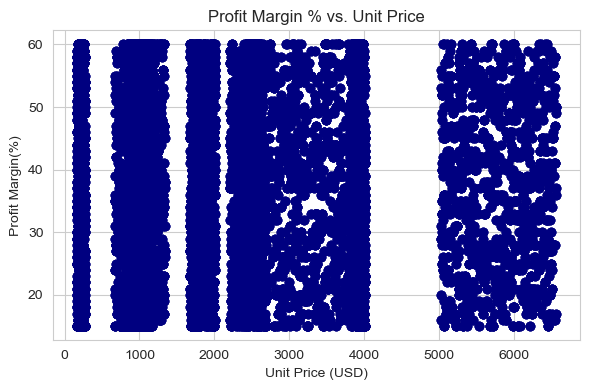

In [53]:
# Calculate profit margin percentage for each record
df['profit_margin_pct'] = (df['profit']/df['revenue'])*100

# Set the figure size for clarity
plt.figure(figsize=(6, 4))

# Plot unit price vs. profit margin percentage
plt.scatter(
    df['unit_price'],
    df['profit_margin_pct'],
    alpha=0.6,
    color='navy'
)
# Adding titile and axis labels
plt.title('Profit Margin % vs. Unit Price')
plt.xlabel('Unit Price (USD)')
plt.ylabel('Profit Margin(%)')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

### Insights ---

Profit margins are concentrated between ~18% and 60% with no clear correlation to unit price, which spans form near $0 to over $6,500.

Dense horizontal bands indicate consitent margins tiers across a wide price spectrum, reflecting uniform pricing startegies.

Outliers below 18% at both low and high price points may signal cost inefficienceis or pricing issues worth deeper investigations.


### 8. Unit Price Distribution per Product

Goal: Compare pricing variability across different products to Identify price consistency and outliers

Chart:Boxplot

EDA Type:Bivariate

Structure:Boxplot with rotated labels to display unit price spread per product


Saved: visuals/chart_8.png


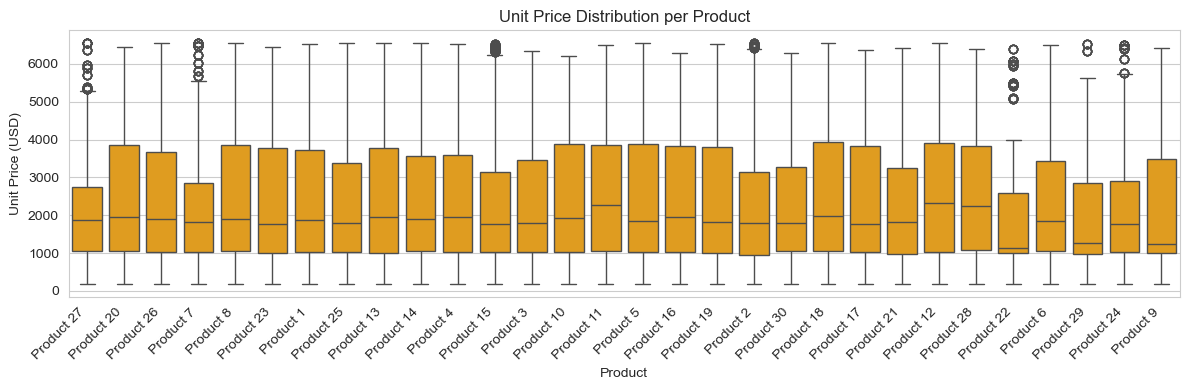

In [54]:
# Set figure size for clarity
plt.figure(figsize=(12, 4))

# Create a boxplot of unit_price by product name

sns.boxplot(
    data=df,
    x='product_name',
    y='unit_price',
    color='orange'
)

# Adding title and lables
plt.title('Unit Price Distribution per Product')
plt.xlabel('Product')
plt.ylabel('Unit Price (USD)')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

## Insights ---

Products 8, 17, 27, 20 and 28 show high-end revenue spikes-well above their upper whiskers-likely due to bulk orders, special-edition releases, or premium bundles that temporarily inflate earnings.

In contrast, deep low-end outliers (near $0-$100) on Products 20 and 27 suggest promotional giveaways or test SKUs that pull down average prices.

To ensure accurate margin and pricing assessments, exclude these outlier transactions from average calculations.


## 9. Total Sales by US Region

Goal:Compare total sales across U.S. regions to identify top-performing markets and ares for target growth.

Chart:Horizontal bar chart

EDA Type: Univariate comparison

Structre:

1.  Bars sorted ascending (Northeast -> West) for clear bottom-to-top ranking
2.  X-axis in millions USD, Y-axis listing regions


C:\Users\Mudit PC\AppData\Local\Temp\ipykernel_25504\3224558207.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved: visuals/chart_9.png


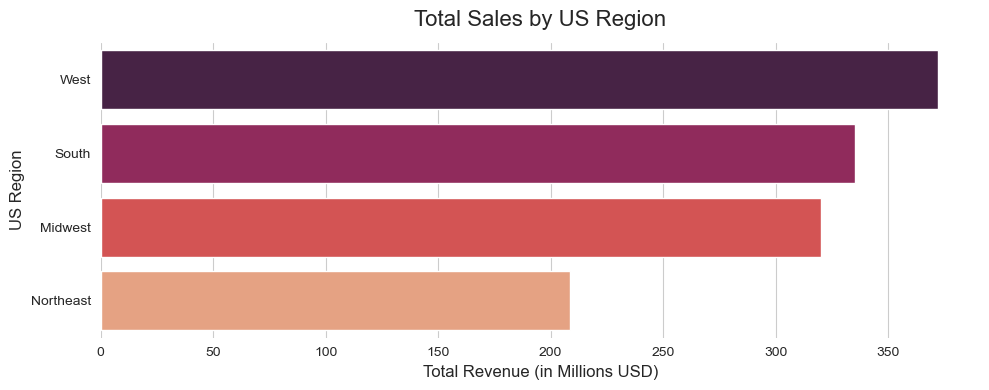

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate total sales by region (in millions)
region_sales = (df.groupby('region')['revenue']
                .sum()
                .sort_values(ascending=False)
                / 1e6
                )

# 2. Plot
plt.figure(figsize=(10, 4))
sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    palette='rocket'
)

# 3. Formatting
plt.title('Total Sales by US Region', fontsize=16, pad=12)
plt.xlabel('Total Revenue (in Millions USD)', fontsize=12)
plt.ylabel('US Region', fontsize=12)
plt.xticks(rotation=0)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Regional Sales Insights

#### Regional Performance

- **West Region** dominates with approximately **$360M in sales (~35% of total revenue)**, highlighting strong market leadership.
- **South and Midwest** each contribute more than **$320M (~32%)**, indicating strong and consistent demand across central regions.
- **Northeast** generates roughly **$210M (~20%)**, suggesting potential room for growth and targeted market expansion.

**Strategic Insight:**  
Focus on closing the **Northeast performance gap** through localized promotions, targeted marketing, and strategic partnerships while maintaining the successful national strategy used in higher-performing regions.

---

#### State-Level Performance

**Top-performing state**

- **California**
  - Revenue: ~**$230M**
  - Orders: **7,500+**

California significantly outperforms all other states, generating **more than twice the revenue of the next-highest market**.

---

**Second-tier markets**

- **Illinois**
- **Florida**
- **Texas**

These states each generate approximately **$85M – $110M in revenue** with **3,600 – 4,600 orders**, representing strong and stable regional demand.

---

**Mid-tier markets**

- **New York**
- **Indiana**

These markets produce around **$54M – $55M in revenue** with roughly **2,500 orders**.

---

**Lower-performing markets**

- **Connecticut**
- **Michigan**
- **Massachusetts**

Revenue ranges between **$35M – $44M** with approximately **1,600 – 2,100 orders**.

---

#### Order Value Insight

The close alignment between **revenue and order counts across states** suggests relatively consistent **average order values**.

**Growth Opportunities**

- Increase **order volume in mid-tier states**
- Improve **average order value in lower-performing regions**
- Expand marketing and distribution in underpenetrated markets

## 10. _Total Sales by State (Choropleth Map)_

**Goal:** Visualize geographic distribution of sales to identify high- and low-performing states and uncover regional gaps.

**Chart:** US choropleth map

**EDA Type:** Univariate geospatial

**Structure:**

- States shaded by total sales (in millions USD) using a blue gradient
- Legend on the right showing sales scale (M USD)
- Hover tooltips display exact sales for each state
- Map scoped to USA for clear regional context


In [56]:
import plotly.express as px

# 1. Aggregate total sales by region (in millions)
state_sales = (df.groupby('state')['revenue']
               .sum()
               .reset_index()
               )
state_sales['revenue_m'] = state_sales['revenue']/1e6

# 2. Plotly choropleth
fig = px.choropleth(
    state_sales,
    locations='state',
    locationmode='USA-states',
    scope='usa',
    color='revenue_m',
    color_continuous_scale='tealrose',
    labels={'revenue_m': 'Total Revenue (in Millions USD)'},
    hover_data={'revenue_m': ':,.2f'},
)

# 3. Layout tuning
fig.update_layout(
    title_text='Total Sales by State',
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(
        title='Sales (M USD)',
        ticksuffix='M',
    )
)
fig.show()

Saved: visuals/chart_10.png


### INSIGHTS —

- **California leads** with \$230 M, followed by Illinois (\$112 M) and Florida (\$90 M), forming a dominant top‑tier (> \$90 M).
- **Mid‑tier states** (e.g., Texas \$85 M, New York \$55 M) hold steady performance but trail the top three by 40–145 M.
- **Lower‑tier states** (e.g., New Jersey \$47 M down to Massachusetts \$35 M) reveal a gradual drop, indicating uneven market penetration.
- **Action:** Double down on top states with tailored promotions, and launch targeted growth initiatives in under‑penetrated regions to close the gap.


## 11. _Top 10 States by Revenue and Order Count_

Goal: Identify highest revenue-generating states and compare their order volumes

Chart: Two bar charts

EDA Type: Multivariate

Structure: First chart shows top 10 states by revenue (in millions), second shows top 10 states by number of orders


C:\Users\Mudit PC\AppData\Local\Temp\ipykernel_25504\3148918472.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Mudit PC\AppData\Local\Temp\ipykernel_25504\3148918472.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Saved: visuals/chart_11.png


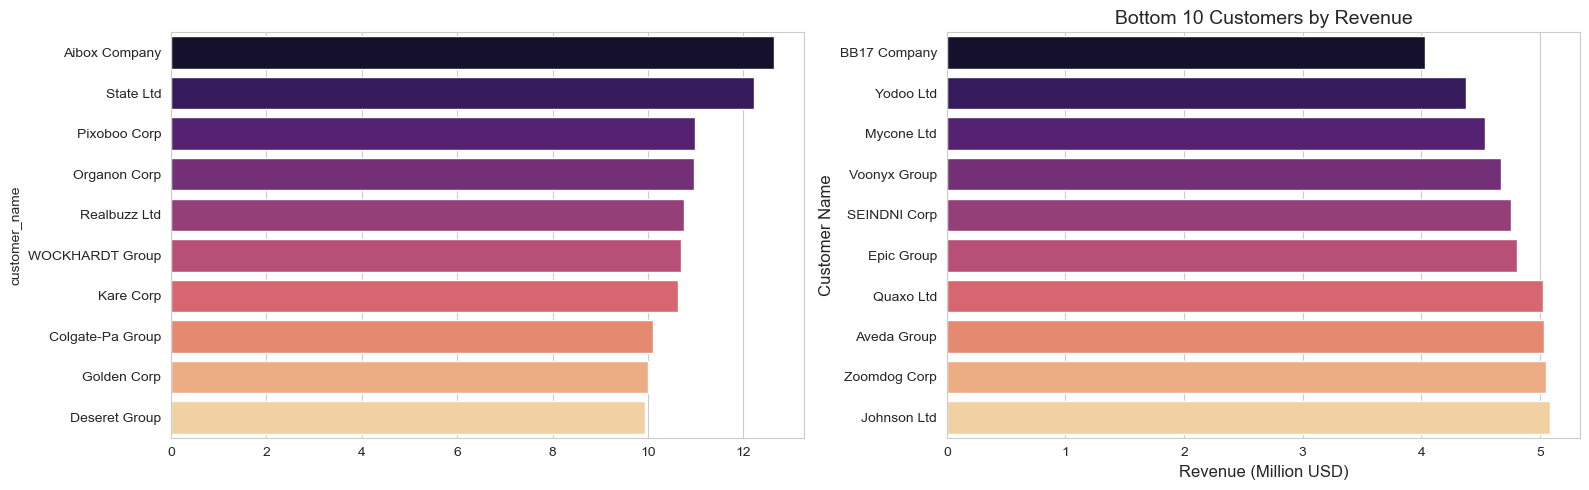

In [57]:
# 1 .Calculate total revenue per customer and select top 10
top_rev = (
    df.groupby('customer_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# 2 .Caluculate total revenue per customer and select bottom 10
bottom_rev = (
    df.groupby('customer_name')['revenue']
    .sum()
    .sort_values(ascending=True)
    .head(10)
)
# 3 .Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Top 10 customers by revenue (converted to millions)
sns.barplot(
    x=top_rev.values/1e6,
    y=top_rev.index,
    ax=axes[0],
    palette='magma'
)

# Plot 2: Bottom 10 customers by revenue (converted to millions)
sns.barplot(
    x=bottom_rev.values/1e6,
    y=bottom_rev.index,
    ax=axes[1],
    palette='magma'
)
axes[1].set_title('Bottom 10 Customers by Revenue', fontsize=14)
axes[1].set_xlabel('Revenue (Million USD)', fontsize=12)
axes[1].set_ylabel('Customer Name', fontsize=12)

# Adjust layout to prevent overlap and display both charts
plt.tight_layout()
plt.show()

## Insights ---

- Aibox Company tops the lists with \$12.5M, followed closely by state ltd (\$12.2 M), while the 10th - ranked Desert Group still contributes \$9.9 M-demonstrating a tight \$10-12 M top tier.

- At the bottom, Johnson ltd leads its group with \$5.1 M, down to BB17 Company at \$4.1 M-roughly half the top customer's revenue.

- This steep drop from ~\$10 M+ to \$4-5 M highlights high revenue concentration among the top customers.

- Action: prioritize retention and upsell for your top ten, and launch targeted growth campaigns to elevate the lower-revenue cohort.


## 12. _Average Profit Margin by Channel_

Goal: Compare average profit margins across sales channels to identify the most and least profitable routes

Chart: Bar chart

EDA Type: Bivariate

Structure: Vertical bars with data labels showing margin percentages, sorted descending by channel


C:\Users\Mudit PC\AppData\Local\Temp\ipykernel_25504\3611242263.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Saved: visuals/chart_12.png


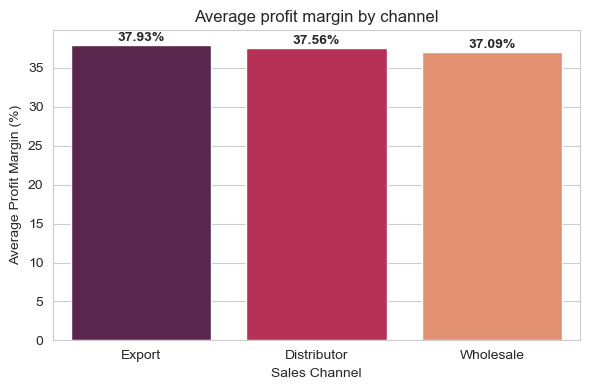

In [58]:
# 1. Compute average profit margin percentage for each channel

channel_margin = (
    df.groupby('channel')['profit_margin_pct']
    .mean()
    .sort_values(ascending=False)
)
# 2. Set the figure size for clarity
plt.figure(figsize=(6, 4))

# 3. Plotting bar chart of average profit margin by channel
ax = sns.barplot(
    x=channel_margin.index,
    y=channel_margin.values,
    palette='rocket'
)

# 4. Add title and axis labels
plt.title('Average profit margin by channel')
plt.xlabel('Sales Channel')
plt.ylabel('Average Profit Margin (%)')

# 5. Annotate each bar with its exact margin percentage
for i, v in enumerate(channel_margin.values):
    ax.text(
        i,
        v+0.5,
        f"{v:.2f}%",
        ha='center',
        fontweight='bold'
    )
# 6 Adjust layout to prevent clipping and display the plot
plt.tight_layout()
plt.show()

### INSIGHTS ---

Export leads with a 37.93 % average margin, closely followed by Distributor (37.56 %) and Wholesale (37.09 %).

The tiny spread (<0.2 %) shows consistently strong profitability across all channels.

This uniformity implies well-controlled costs and pricing power everywhere.

To maximize returns, push volume growth in Export while maintaining efficiency in Distributor and Wholesale.


## 13. _Top and Bottom 10 Customers by Revenue_

Goal: Identify your highest- and lowest-revenue customers to tailor engagement strategies

Chart: Side-by-side horizontal bar charts

EDA Type: Multivariate

Structure: Left chart shows top 10 customers by revenue (in millions), right chart shows bottom 10 customers by revenue (in millions)


C:\Users\Mudit PC\AppData\Local\Temp\ipykernel_25504\575810476.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Saved: visuals/chart_13.png


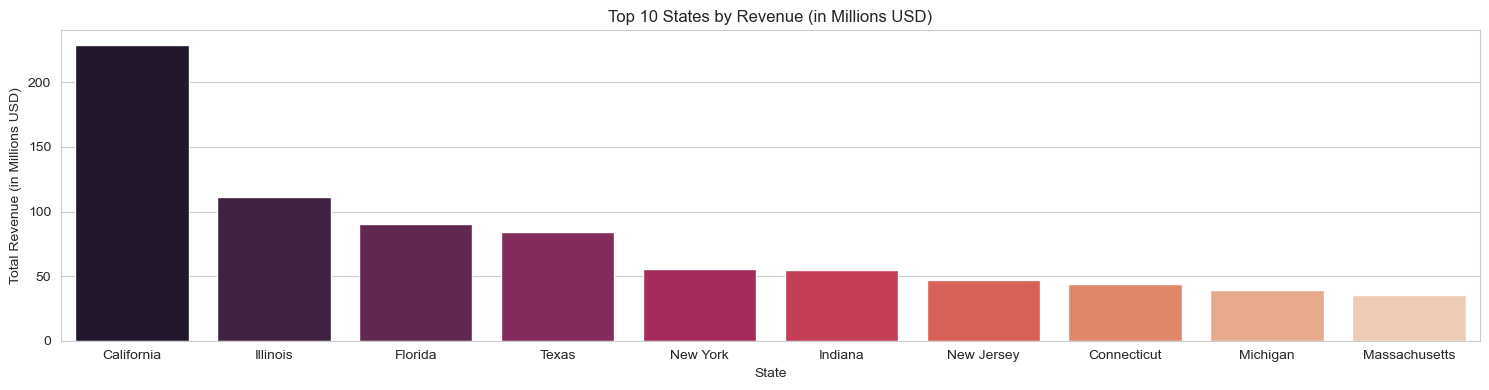

C:\Users\Mudit PC\AppData\Local\Temp\ipykernel_25504\575810476.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Saved: visuals/chart_14.png


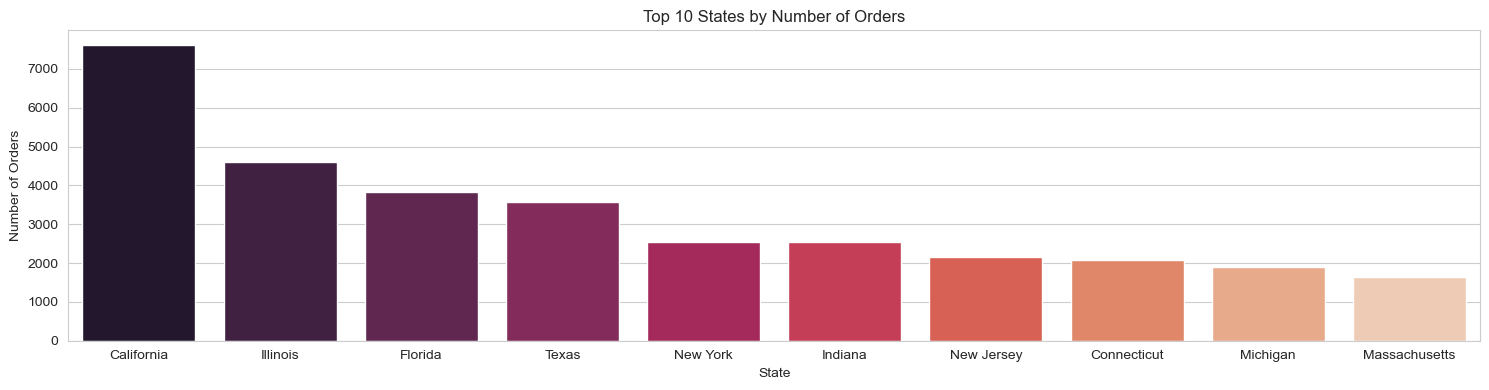

In [59]:
# 1. Aggregate total revenue ana unique order count per state
state_rev = df.groupby('state').agg(revenue=('revenue', 'sum'),
                                    orders=('order_number', 'nunique')
                                    ).sort_values('revenue', ascending=False).head(10)

# Plot 1: Top 10 states by revenue (scaled to millions)
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,
    y=state_rev['revenue']/1e6,
    palette='rocket'
)
plt.title('Top 10 States by Revenue (in Millions USD)')
plt.xlabel('State')
plt.ylabel('Total Revenue (in Millions USD)')
plt.tight_layout()
plt.show()

# Plot 2: Top 10 states by number of orders
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,
    y=state_rev['orders'],
    palette='rocket'
)
plt.title('Top 10 States by Number of Orders')
plt.xlabel('State')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

## 14. _Customer Segmentation: Revenue vs. Profit Margin_

Goal: Segment customers by total revenue and average profit margin, highlighting order volume

Chart: Bubble chart (scatter plot with variable point sizes)

EDA Type: Multivariate

Structure: Scatter points sized by number of orders, plotting revenue vs. margin


Saved: visuals/chart_15.png


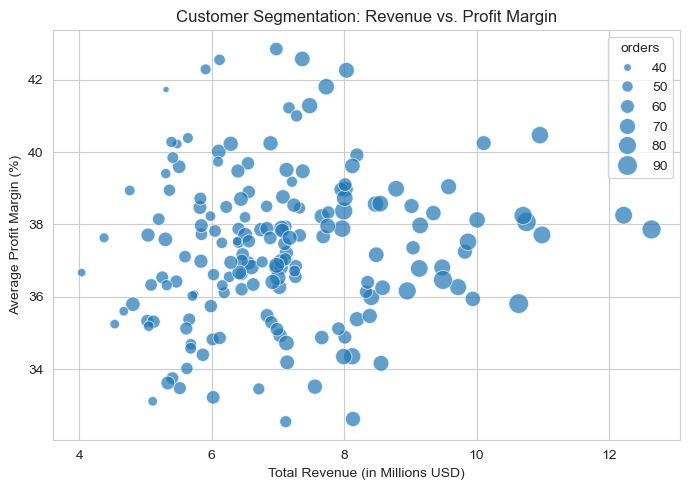

In [60]:
# 1 .Aggregate metrics per customer
cust_summary = df.groupby('customer_name').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin_pct', 'mean'),
    orders=('order_number', 'nunique')
)

# Convert revenue to millions
cust_summary['total_revenue_m'] = cust_summary['total_revenue']/1e6
plt.figure(figsize=(7, 5))

# Convert revenue to million
sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',
    y='avg_margin',
    size='orders',
    sizes=(20, 200),
    alpha=0.7
)
plt.title('Customer Segmentation: Revenue vs. Profit Margin')
plt.xlabel('Total Revenue (in Millions USD)')
plt.ylabel('Average Profit Margin (%)')
plt.tight_layout()
plt.show()

### INSIGHTS ---

- Customers with >\$10 M in revenue tend to sustain margins between 36–40%, indicating that scale does not significantly erode profitability.
- Most customers cluster within the \$6–10 M range and show stable margins (~34–40%), suggesting consistent pricing in this tier.
- Customers below \$6 M display the widest margin variance (~33–43%), pointing to more volatile cost structures or discounts among smaller accounts.
- Bubble size (order count) increases with revenue, but margin levels appear unaffected—reinforcing revenue as the dominant performance driver over order volume.


## 15. _Correlation Heatmap of Numeric Features_

Goal: Identify relationships among key numeric variables to uncover potential multicollinearity

Chart: Correlation heatmap

EDA Type: Multivariate

Structure: Annotated heatmap with correlation coefficients for selected numeric columns


In [61]:
df.head(1)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,...,latitude,longitude,median_income,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num,order_month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,32.08354,-81.09983,36466,NaN,10946.058,4048.542,27.0,January,1,2014-01


Saved: visuals/chart_16.png


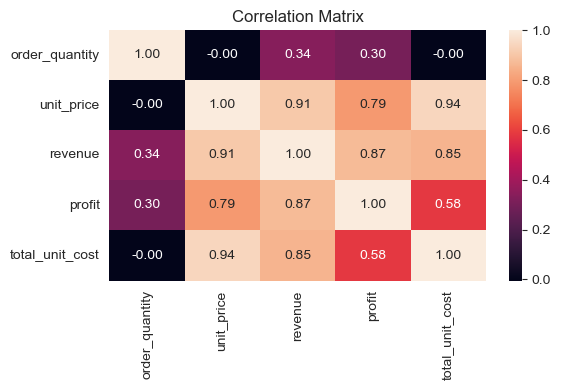

In [62]:
# List numeric columns to include in the correlation calculation
num_cols = ['order_quantity', 'unit_price',
            'revenue', 'profit', 'total_unit_cost']

# Calculate the correlation matrix for these numeric features
corr = df[num_cols].corr()

# Set the figure size for better visibility
plt.figure(figsize=(6, 4))

# Plot the heatmap with annotations and a custom color map
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='rocket'
)

# Add a title and show the plot
plt.title('Correlation Matrix')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

### INSIGHTS ---

- **Profit and revenue** are very strongly correlated (0.87), indicating that as sales value increases, profit tends to rise as well.
- **Unit price** is a key driver: it correlates 0.91 with revenue, 0.79 with profit, and 0.94 with cost—highlighting how pricing decisions ripple through both top‑line and expense figures.
- **Cost** shows a strong link to revenue (0.85) but a more moderate tie to profit (0.58), underscoring that while higher sales often bring higher expenses, margins can still vary.
- **Quantity** has virtually no correlation with unit price or cost (≈0.00) and only modest associations with revenue (0.34) and profit (0.30), making volume a secondary factor compared to pricing.


# **Saving Pre-Processed Dataframe**


In [63]:
df

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,...,latitude,longitude,median_income,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num,order_month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,32.08354,-81.09983,36466,NaN,10946.058,4048.542,27.0,January,1,2014-01
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,39.61366,-86.10665,54176,NaN,13969.098,11899.602,46.0,January,1,2014-01
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,37.66243,-121.87468,124759,NaN,4108.440,1760.760,30.0,January,1,2014-01
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,39.16533,-86.52639,30019,NaN,7201.964,9166.136,56.0,January,1,2014-01
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,41.77524,-72.52443,63158,NaN,10082.160,8249.040,45.0,January,1,2014-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,...,40.15511,-74.82877,69878,NaN,11765.736,10022.664,46.0,February,2,2018-02
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,...,42.11030,-88.03424,71573,NaN,3474.486,1711.314,33.0,February,2,2018-02
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,...,26.24453,-80.20644,42786,NaN,29133.610,14349.390,33.0,February,2,2018-02
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,...,42.91002,-78.74182,48662,NaN,20511.246,7206.654,26.0,February,2,2018-02


In [64]:
# Export Final DataFrame to CSV
df.to_csv('mudit_sales_data_eda_completed_final.csv', index=False)

## Key Insights

### 1. Revenue Stability and Monthly Trends
Revenue remains relatively stable between **$23M and $26.5M** during the 2014–2017 period, with no strong recurring seasonal spikes.

However, a noticeable decline occurs in **early 2017**, where revenue drops to approximately **$21.2M**, potentially indicating a **temporary market disruption or operational anomaly**.

---

### 2. Sales Channel Distribution

| Channel | Share of Total Revenue |
|--------|------------------------|
| Wholesale | 54% |
| Distributors | 31% |
| Export | 15% |

Sales are heavily concentrated in the **Wholesale channel**, suggesting a strong reliance on bulk distribution. The relatively smaller export share indicates a **potential opportunity to expand international markets**.

---

### 3. Top Revenue-Generating Products

**Top performers**

- **Product 26:** $118M  
- **Product 25:** $110M  
- **Product 13:** $78M  

**Mid-tier performers**

- Products generating approximately **$68M – $75M**

**Lower-performing products**

- Products generating approximately **$52M – $57M**

This distribution indicates that **a small number of products contribute a significant share of total revenue**.

---

### 4. Profit Margin Distribution

Profit margins range broadly from approximately **18% to 60%**.

Key observations:

- No strong correlation between **unit price and profit margin**
- Horizontal clustering suggests **standardized pricing strategies across product tiers**

---

### 5. Seasonal Sales Volume

Monthly sales volumes show **limited seasonal variation**, although a slight increase in demand appears during **May–June**.

The **early 2017 revenue dip (~$21.2M)** stands out as an anomaly and may require further investigation.

---

### 6. Regional Sales Performance

**Top-performing market**

- **California**
  - Revenue: ~**$230M**
  - Orders: **7500+**

**Mid-tier markets**

- **Illinois, Florida, Texas**
  - Revenue: **$85M – $110M**
  - Orders: **3500 – 4500**

**Lower-volume markets**

- **New York, Indiana**
  - Revenue: ~**$54M**
  - Orders: **2000+**

These patterns highlight **regional demand concentration**, with California acting as the primary revenue driver.

# **Recommendations**

1. **Outlier Strategy:** Exclude or formalize bulk-order and promotional SKUs when calculating averages.

2. **Margin Uplift:** Apply top-product pricing levers to mid/low tiers; cut costs on underperformers.

3. **Export Growth:** Invest in targeted overseas marketing and distributor partnerships.

4. **Seasonal Planning:** Shift spend toward January trough and May–June peak; investigate the 2017 anomaly.

5. **Dashboard Prep:** Build aggregated tables for time series, channel mix, and product performance for Power BI.
